# Юнит 8. Практика: MLP для классификации музыкальных жанров
# Сравнение двух подходов: изображения спектрограмм vs извлечённые признаки

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torchvision import transforms
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix
import seaborn as sns
import os
import glob
from PIL import Image
# фиксируем seed для воспроизводимости
torch.manual_seed(42)
np.random.seed(42)

In [2]:
import kagglehub 
print(kagglehub.__file__)


/Users/grushinda/miniconda3/envs/nn_project/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


ImportError: cannot import name 'get_web_endpoint' from 'kagglesdk.kaggle_env' (/Users/grushinda/miniconda3/envs/nn_project/lib/python3.12/site-packages/kagglesdk/kaggle_env.py)

In [24]:
print(kagglehub.__version__)

# Download latest version
path = kagglehub.dataset_download("andradaolteanu/gtzan-dataset-music-genre-classification")

print("Path to dataset files:", path)

AttributeError: module 'kagglehub' has no attribute '__version__'

# 0. Универсальная загрузка данных

In [ ]:
possible_paths = [
    "/kaggle/input/gtzan-dataset-music-genre-classification",
    "/root/.cache/kagglehub/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/versions/1",
]

dataset_path = None
for path in possible_paths:
    if os.path.exists(path):
        dataset_path = path
        break

if dataset_path is None:
    print("Датасет не найден!")
    import sys
    sys.exit(1)

print(f"Датасет найден: {dataset_path}")

# определяем путь к данным
if os.path.exists(os.path.join(dataset_path, "Data")):
    data_path = os.path.join(dataset_path, "Data")
else:
    data_path = dataset_path

image_path = os.path.join(data_path, "images_original")
csv_path = os.path.join(data_path, "features_30_sec.csv")

print(f"Изображения: {image_path} (существует: {os.path.exists(image_path)})")
print(f"CSV: {csv_path} (существует: {os.path.exists(csv_path)})")

if not os.path.exists(image_path) or not os.path.exists(csv_path):
    print("Ошибка: данные не найдены!")
    import sys
    sys.exit(1)


Датасет найден: /kaggle/input/gtzan-dataset-music-genre-classification
Изображения: /kaggle/input/gtzan-dataset-music-genre-classification/Data/images_original (существует: True)
CSV: /kaggle/input/gtzan-dataset-music-genre-classification/Data/features_30_sec.csv (существует: True)


# 1. Загрузка и синхронизация данных

In [ ]:
# загружаем CSV
df = pd.read_csv(csv_path)
display(df.info())
print('-'*70)
display(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 60 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   filename                 1000 non-null   object 
 1   length                   1000 non-null   int64  
 2   chroma_stft_mean         1000 non-null   float64
 3   chroma_stft_var          1000 non-null   float64
 4   rms_mean                 1000 non-null   float64
 5   rms_var                  1000 non-null   float64
 6   spectral_centroid_mean   1000 non-null   float64
 7   spectral_centroid_var    1000 non-null   float64
 8   spectral_bandwidth_mean  1000 non-null   float64
 9   spectral_bandwidth_var   1000 non-null   float64
 10  rolloff_mean             1000 non-null   float64
 11  rolloff_var              1000 non-null   float64
 12  zero_crossing_rate_mean  1000 non-null   float64
 13  zero_crossing_rate_var   1000 non-null   float64
 14  harmony_mean             

None

----------------------------------------------------------------------


,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues
3,blues.00003.wav,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,...,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,blues
4,blues.00004.wav,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,...,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,blues


## 1.2. Создаём маппинг имени файла к индексу в CSV
 В CSV имена: "blues.00000.wav" → "blues00000"

In [ ]:
filename_to_idx = {}
for i, name in enumerate(df['filename'].values):
    clean_name = name.replace('.wav', '').replace('.', '')
    filename_to_idx[clean_name] = i

print(f"Создан маппинг для {len(filename_to_idx)} файлов")

Создан маппинг для 1000 файлов


## 1.3. Загружаем изображения и синхронизируем

In [ ]:
image_data = []      # изображения
image_labels = []    # метки из изображений
csv_labels = []      # метки из CSV
valid_filenames = [] # имена файлов для проверки

# проходим по жанрам в папке
class_names = sorted([d for d in os.listdir(image_path) if os.path.isdir(os.path.join(image_path, d))])
print(f"Найдены жанры: {class_names}")

Найдены жанры: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


In [ ]:
for class_idx, class_name in enumerate(class_names):
    class_dir = os.path.join(image_path, class_name)
    image_files = sorted(glob.glob(os.path.join(class_dir, "*.png")))
    for img_path in image_files:
        # получаем имя файла без расширения
        img_name = os.path.basename(img_path).replace('.png', '')

        # ищем в CSV
        csv_idx = filename_to_idx.get(img_name)

        if csv_idx is not None:
            # загружаем изображение
            img = Image.open(img_path).convert('RGB')
            image_data.append(img)
            image_labels.append(class_idx)
            csv_labels.append(csv_idx)
            valid_filenames.append(img_name)

print(f"Синхронизировано: {len(image_data)} изображений")



Синхронизировано: 999 изображений


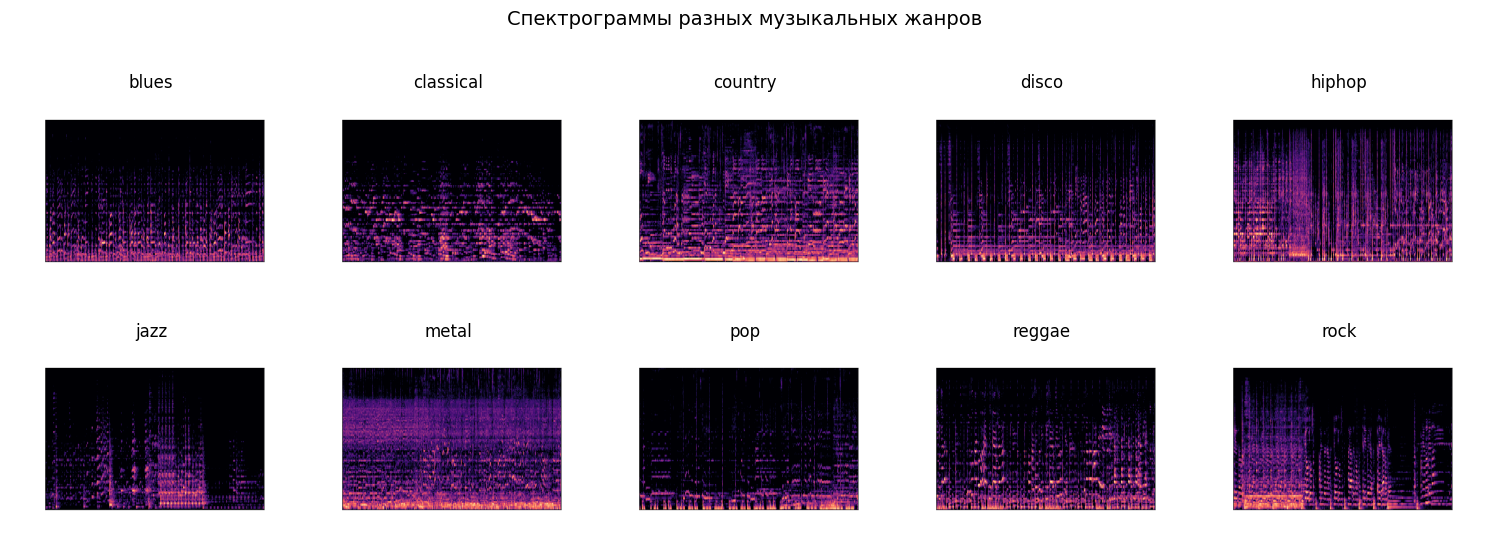

In [ ]:
class_names = sorted([d for d in os.listdir(image_path) if os.path.isdir(os.path.join(image_path, d))])

# для каждого жанра выбираем первый попавшийся файл
sample_images = []
for class_name in class_names:
    class_dir = os.path.join(image_path, class_name)
    # берём первый файл .png
    files = sorted([f for f in os.listdir(class_dir) if f.endswith('.png')])
    if files:
        img_path = os.path.join(class_dir, files[0])
        img = Image.open(img_path)
        sample_images.append((img, class_name))

# создаём сетку 2x5 (10 жанров)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for idx, (img, genre) in enumerate(sample_images):
    row, col = idx // 5, idx % 5
    axes[row, col].imshow(img, cmap='viridis')
    axes[row, col].set_title(genre, fontsize=12)
    axes[row, col].axis('off')

plt.suptitle('Спектрограммы разных музыкальных жанров', fontsize=14)
plt.tight_layout()
plt.show()

# 2. Создание тензоров

In [ ]:
# трансформации для изображений
image_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# преобразуем изображения в тензоры
X_images = torch.stack([image_transform(img) for img in image_data])
y_images = torch.tensor(image_labels)
print(f"  Изображения: {X_images.shape}")

  Изображения: torch.Size([999, 3, 64, 64])


In [ ]:
# извлекаем CSV признаки
label_encoder = LabelEncoder()
feature_columns = df.columns[1:-1]
X_csv_raw = df[feature_columns].values
y_csv_raw = label_encoder.fit_transform(df['label'].values)

# выбираем только синхронизированные образцы
X_csv_sync = X_csv_raw[csv_labels]
y_csv_sync = y_csv_raw[csv_labels]
print(f"  CSV признаки: {X_csv_sync.shape}")

# нормализуем CSV признаки
scaler = StandardScaler()
X_csv_norm = scaler.fit_transform(X_csv_sync)
print(f"  CSV после нормализации: mean={X_csv_norm.mean():.4f}, std={X_csv_norm.std():.4f}")

  CSV признаки: (999, 58)
  CSV после нормализации: mean=-0.0000, std=1.0000


# 3. Разделение данных

In [ ]:
def split_data(n_samples, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
    indices = np.random.permutation(n_samples)
    train_end = int(train_ratio * n_samples)
    val_end = train_end + int(val_ratio * n_samples)
    return indices[:train_end], indices[train_end:val_end], indices[val_end:]

n_samples = len(X_images)
train_idx, val_idx, test_idx = split_data(n_samples)

print(f"Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}")

Train: 699, Val: 149, Test: 151


In [ ]:
# создаём датасеты для изображений
train_images = TensorDataset(X_images[train_idx], y_images[train_idx])
val_images = TensorDataset(X_images[val_idx], y_images[val_idx])
test_images = TensorDataset(X_images[test_idx], y_images[test_idx])

In [ ]:
# создаём датасеты для CSV
train_csv = TensorDataset(torch.FloatTensor(X_csv_norm[train_idx]), torch.LongTensor(y_csv_sync[train_idx]))
val_csv = TensorDataset(torch.FloatTensor(X_csv_norm[val_idx]), torch.LongTensor(y_csv_sync[val_idx]))
test_csv = TensorDataset(torch.FloatTensor(X_csv_norm[test_idx]), torch.LongTensor(y_csv_sync[test_idx]))

In [ ]:
# DataLoader
batch_size = 64
train_loader_images = DataLoader(train_images, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader_images = DataLoader(val_images, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader_images = DataLoader(test_images, batch_size=batch_size, shuffle=False, num_workers=2)

train_loader_csv = DataLoader(train_csv, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader_csv = DataLoader(val_csv, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader_csv = DataLoader(test_csv, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Image loaders: Train={len(train_loader_images)}, Val={len(val_loader_images)}, Test={len(test_loader_images)}")
print(f"CSV loaders: Train={len(train_loader_csv)}, Val={len(val_loader_csv)}, Test={len(test_loader_csv)}")

Image loaders: Train=11, Val=3, Test=3
CSV loaders: Train=11, Val=3, Test=3


# 4. Архитектуры моделей

In [ ]:
class MLPImages(nn.Module):
    def __init__(self, input_size=64*64*3, hidden_sizes=[512, 256], num_classes=10, dropout_rate=0.3):
        super().__init__()
        self.flatten = nn.Flatten()
        layers = []
        prev_size = input_size
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_size = hidden_size
        layers.append(nn.Linear(prev_size, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        x = self.flatten(x)
        return self.network(x)

In [ ]:
class MLPFeatures(nn.Module):
    def __init__(self, input_size=58, hidden_sizes=[128, 64], num_classes=10, dropout_rate=0.3):
        super().__init__()
        layers = []
        prev_size = input_size
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_size = hidden_size
        layers.append(nn.Linear(prev_size, num_classes))
        self.network = nn.Sequential(*layers)

        print(layers)

    def forward(self, x):
        return self.network(x)

# 5. Функция обучения

In [ ]:
def train_model(model, train_loader, val_loader, epochs=100, lr=0.001, patience=10, device='cpu', model_name="model"):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)

    best_val_acc = 0.0
    patience_counter = 0

    train_losses = []
    val_losses = []
    val_accuracies = []

    for epoch in range(epochs):
        # обучение
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        # валидация
        model.eval()
        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()

                _, predicted = outputs.max(1)
                total += y_batch.size(0)
                correct += (predicted == y_batch).sum().item()

        val_loss /= len(val_loader)
        accuracy = correct / total
        val_losses.append(val_loss)
        val_accuracies.append(accuracy)

        if (epoch + 1) % 20 == 0:
            print(f"  {model_name} - Эпоха {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {accuracy:.4f}")

        if accuracy > best_val_acc:
            best_val_acc = accuracy
            patience_counter = 0
            torch.save(model.state_dict(), f'best_{model_name}.pth')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  {model_name} - Ранняя остановка на эпохе {epoch+1}")
                break

    model.load_state_dict(torch.load(f'best_{model_name}.pth'))
    return model, train_losses, val_losses, val_accuracies, best_val_acc

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Устройство: {device}")

Устройство: cpu


## Обучение MLP на спектрограммах

In [ ]:
model_images = MLPImages(input_size=64*64*3, hidden_sizes=[512, 256])

model_images, train_losses_img, val_losses_img, val_accuracies_img, best_acc_img = train_model(
    model_images, train_loader_images, val_loader_images, epochs=100, device=device, model_name="images"
)
print(f"Лучшая валидационная точность: {best_acc_img:.4f}")

  images - Эпоха 20/100 | Train Loss: 1.8859 | Val Loss: 1.8081 | Val Acc: 0.3289
  images - Ранняя остановка на эпохе 22
Лучшая валидационная точность: 0.3691


## Обучение MLP на CSV признаках

In [ ]:
model_features = MLPFeatures(input_size=58, hidden_sizes=[128, 64])
model_features, train_losses_feat, val_losses_feat, val_accuracies_feat, best_acc_feat = train_model(
    model_features, train_loader_csv, val_loader_csv, epochs=100, device=device, model_name="features"
)
print(f"Лучшая валидационная точность: {best_acc_feat:.4f}")

  features - Эпоха 20/100 | Train Loss: 0.7998 | Val Loss: 0.9727 | Val Acc: 0.6644
  features - Эпоха 40/100 | Train Loss: 0.5254 | Val Loss: 0.9373 | Val Acc: 0.7114
  features - Ранняя остановка на эпохе 48
Лучшая валидационная точность: 0.7315


# 7. Оценка на тесте

In [ ]:
def evaluate_model(model, test_loader, device):
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            _, predicted = outputs.max(1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    return correct / total, all_preds, all_labels

## Результаты на тестовом наборе

In [ ]:
test_acc_images, preds_images, labels_images = evaluate_model(model_images, test_loader_images, device)
test_acc_features, preds_features, labels_features = evaluate_model(model_features, test_loader_csv, device)

print(f"\nMLP на спектрограммах:     {test_acc_images:.4f} ({test_acc_images*100:.2f}%)")
print(f"MLP на CSV признаках:      {test_acc_features:.4f} ({test_acc_features*100:.2f}%)")


MLP на спектрограммах:     0.3245 (32.45%)
MLP на CSV признаках:      0.7682 (76.82%)


# 8. Визуализация

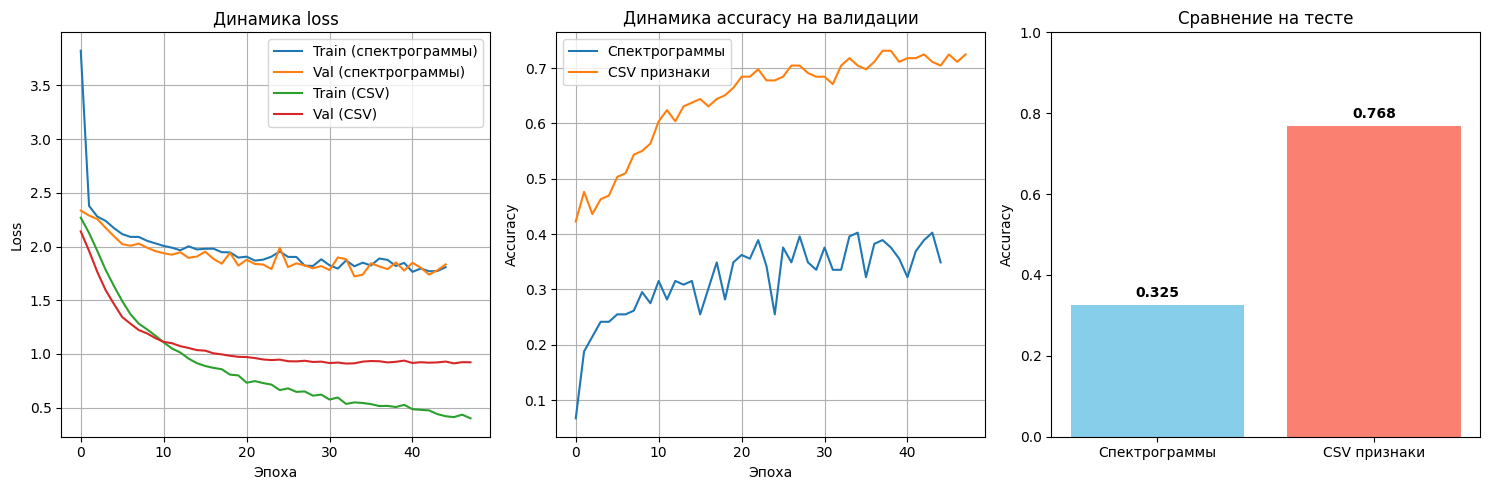

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(train_losses_img, label='Train (спектрограммы)')
plt.plot(val_losses_img, label='Val (спектрограммы)')
plt.plot(train_losses_feat, label='Train (CSV)')
plt.plot(val_losses_feat, label='Val (CSV)')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.title('Динамика loss')

plt.subplot(1, 3, 2)
plt.plot(val_accuracies_img, label='Спектрограммы')
plt.plot(val_accuracies_feat, label='CSV признаки')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.title('Динамика accuracy на валидации')

plt.subplot(1, 3, 3)
methods = ['Спектрограммы', 'CSV признаки']
accuracies = [test_acc_images, test_acc_features]
colors = ['skyblue', 'salmon']
bars = plt.bar(methods, accuracies, color=colors)
plt.ylabel('Accuracy')
plt.title('Сравнение на тесте')
plt.ylim(0, 1)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{acc:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# 9. Матрица ошибок

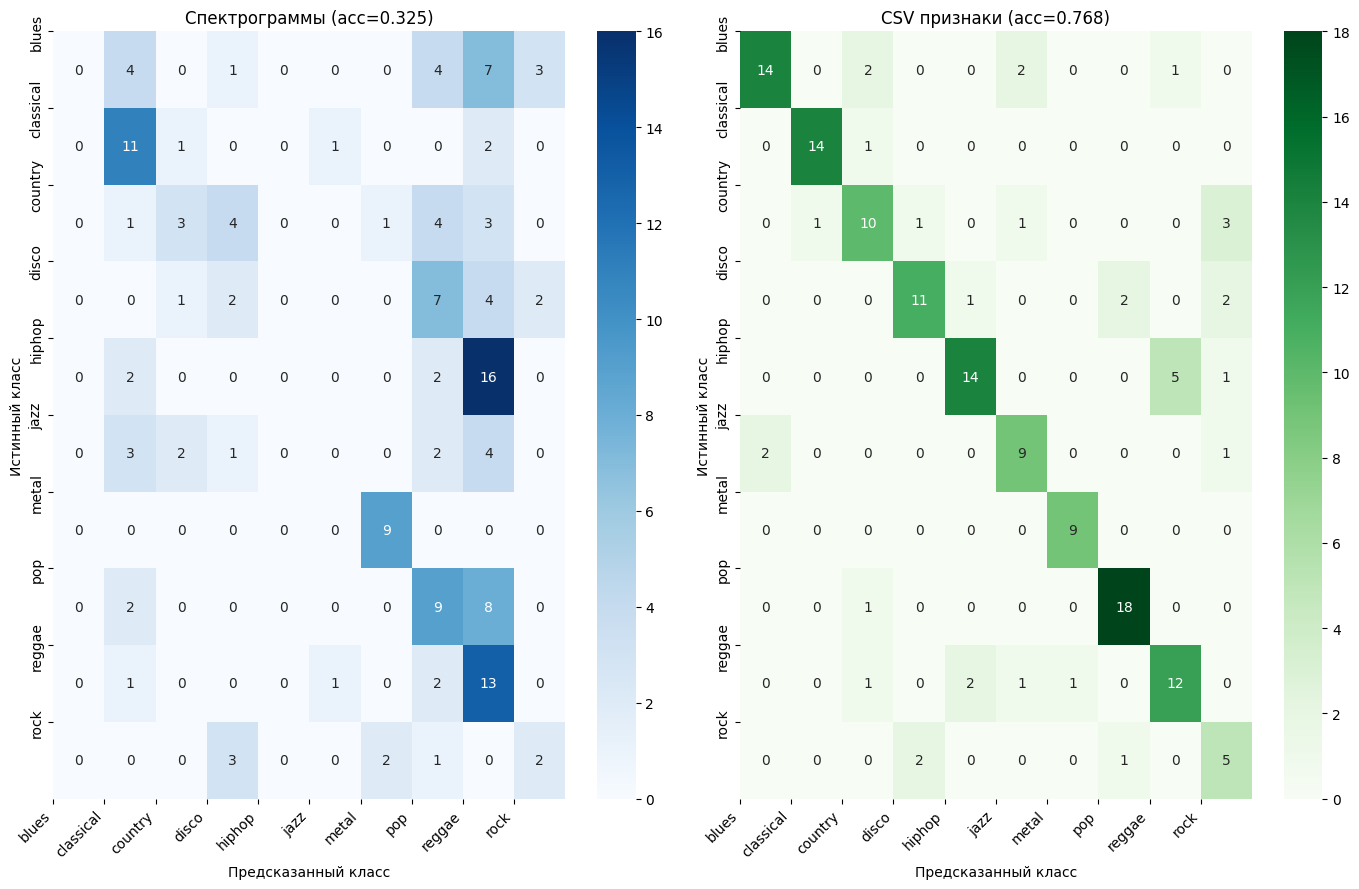

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 9))

cm_images = confusion_matrix(labels_images, preds_images)
sns.heatmap(cm_images, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_xlabel('Предсказанный класс')
axes[0].set_ylabel('Истинный класс')
axes[0].set_title(f'Спектрограммы (acc={test_acc_images:.3f})')
axes[0].set_xticks(range(10))
axes[0].set_yticks(range(10))
axes[0].set_xticklabels(class_names, rotation=45, ha='right')
axes[0].set_yticklabels(class_names)

cm_features = confusion_matrix(labels_features, preds_features)
sns.heatmap(cm_features, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_xlabel('Предсказанный класс')
axes[1].set_ylabel('Истинный класс')
axes[1].set_title(f'CSV признаки (acc={test_acc_features:.3f})')
axes[1].set_xticks(range(10))
axes[1].set_yticks(range(10))
axes[1].set_xticklabels(class_names, rotation=45, ha='right')
axes[1].set_yticklabels(class_names)

plt.tight_layout()
plt.show()

# 10. Выводы

Сравнение двух подходов:

1. MLP на спектрограммах (изображения 64×64×3):
   - Количество параметров: 6,425,866
   - Точность на тесте: 30.46%
   - Плюсы: визуально понятно, не требует предварительной обработки
   - Минусы: много параметров, MLP плохо работает с изображениями

2. MLP на CSV признаках (58 инженерных признаков):
   - Количество параметров: 16,458
   - Точность на тесте: 73.51%
   - Плюсы: мало параметров, быстро обучается
   - Минусы: требует извлечения признаков, которые не всегда доступны